<a href="https://colab.research.google.com/github/Nikhilvijai/internship/blob/main/image_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image

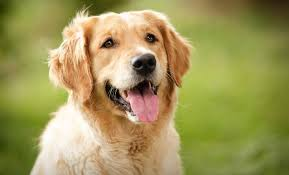

In [ ]:
image = Image.open("/content/images.jpg")
image_resize = image.resize((400,224))
image

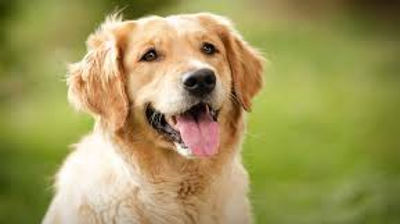

In [ ]:
image_resize

In [ ]:
import numpy as np

image_arry = np.array(image)/255
image_arry

array([[[0.21568627, 0.24705882, 0.05490196],
        [0.21568627, 0.24705882, 0.05490196],
        [0.21960784, 0.25098039, 0.05882353],
        ...,
        [0.17254902, 0.12156863, 0.04705882],
        [0.16862745, 0.1254902 , 0.04705882],
        [0.17647059, 0.13333333, 0.05490196]],

       [[0.20784314, 0.23921569, 0.04705882],
        [0.21176471, 0.24313725, 0.05098039],
        [0.21568627, 0.24705882, 0.05490196],
        ...,
        [0.17647059, 0.1254902 , 0.05098039],
        [0.17254902, 0.12941176, 0.05098039],
        [0.18039216, 0.1372549 , 0.05882353]],

       [[0.2       , 0.23137255, 0.03921569],
        [0.20392157, 0.23529412, 0.04313725],
        [0.21176471, 0.24313725, 0.04313725],
        ...,
        [0.18431373, 0.13333333, 0.05882353],
        [0.18039216, 0.1372549 , 0.05882353],
        [0.18431373, 0.14117647, 0.0627451 ]],

       ...,

       [[0.26666667, 0.31372549, 0.0627451 ],
        [0.26666667, 0.31372549, 0.0627451 ],
        [0.27058824, 0

array([[47, 47, 48, ..., 27, 27, 29],
       [45, 46, 47, ..., 28, 28, 30],
       [43, 44, 46, ..., 30, 30, 31],
       ...,
       [59, 59, 60, ..., 72, 72, 73],
       [55, 56, 57, ..., 73, 73, 72],
       [53, 54, 55, ..., 74, 74, 70]], dtype=uint8)
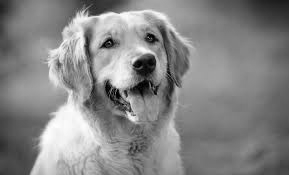

In [ ]:
from cv2 import cvtColor, COLOR_BGR2GRAY

image_np = np.array(image)
greyscale_image = cvtColor(image_np, COLOR_BGR2GRAY)
greyscale_image

#image augmentaion

In [ ]:
from PIL import Image, ImageEnhance,ImageOps
import os

In [ ]:
flipped = ImageOps.mirror(image)

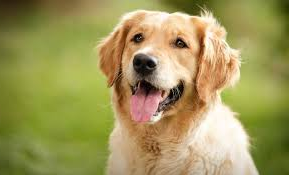

In [ ]:
flipped

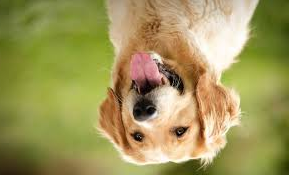

In [ ]:
rotated = image.rotate(180)
rotated

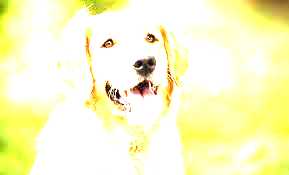

In [ ]:
enhanc = ImageEnhance.Brightness(image)
brighter = enhanc.enhance(3)
brighter

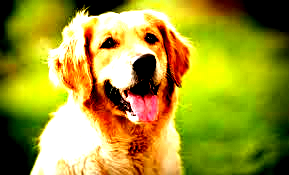

In [ ]:
contrast = ImageEnhance.Contrast(image).enhance(3)
contrast

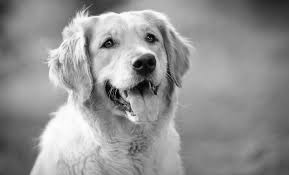

In [ ]:
grayscale = ImageOps.grayscale(image)
grayscale

In [ ]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/images.jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


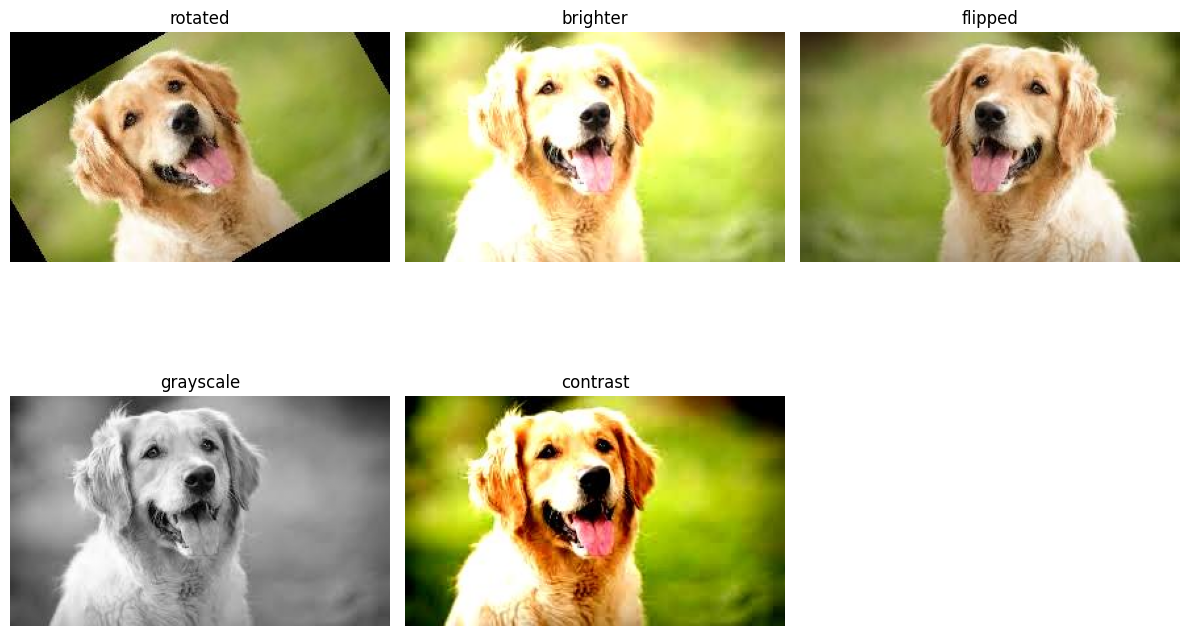

In [ ]:
import matplotlib.pyplot as plt

augmented_dir = "augmented_images"

augmented_images = os.listdir(augmented_dir)

plt.figure(figsize=(12,8))

for i,img_file in enumerate(augmented_images):
    img_path = os.path.join(augmented_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="grey" if img.mode == "L" else None)
    plt.title(img_file.split('.')[0])
    plt.axis('off')

plt.tight_layout()
plt.show()